# Week 2 Lab — Trees, Bagging, Boosting, KNN, and Text Naive Bayes

**Synthetic-data disclaimer:** Every record and message in this notebook is generated for instruction. The models are teaching examples, not production detection systems. They must not be used to label real people, hosts, domains, or messages.

The instructor-guided sequence mirrors the live lesson: establish evaluation discipline, fit one controlled tree, reduce variance with bagging and random forests, add sequential boosting, compare scaled KNN, and finish with count-based text classification.

In [ ]:
# Setup, imports, and version check
import inspect
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 207
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 20)

print("Python:", sys.version.split()[0])
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("All data are synthetic; all models are teaching examples.")

Python: 3.13.14
scikit-learn: 1.9.0
NumPy: 2.5.1
pandas: 3.0.5
All data are synthetic; all models are teaching examples.


## 1. Generate synthetic imbalanced defensive features

The features imitate measurements available before an analyst disposition: URL length, digit ratio, an entropy-like score, suspicious token count, domain age, message-link count, and path depth. The target is intentionally imbalanced.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
n_samples = 1400

X = pd.DataFrame({
    "url_length": np.clip(rng.gamma(4.0, 15.0, n_samples) + 12, 10, 260),
    "digit_ratio": rng.beta(1.8, 7.0, n_samples),
    "entropy_score": np.clip(rng.normal(3.7, 0.75, n_samples), 1.0, 7.0),
    "suspicious_token_count": rng.poisson(0.9, n_samples),
    "domain_age_days": np.clip(rng.lognormal(6.0, 1.25, n_samples), 1, 6000),
    "message_link_count": rng.poisson(1.1, n_samples),
    "path_depth": rng.poisson(2.2, n_samples),
})

risk = (
    0.022 * (X["url_length"] - 65)
    + 5.2 * (X["digit_ratio"] - 0.20)
    + 0.65 * (X["entropy_score"] - 3.8)
    + 0.72 * X["suspicious_token_count"]
    - 0.0015 * X["domain_age_days"]
    + 0.30 * X["message_link_count"]
    + 0.16 * X["path_depth"]
    - 2.4
    + rng.normal(0, 1.0, n_samples)
)
y = pd.Series((risk > 0).astype(int), name="suspicious")

print(X.head())
print("\nClass distribution")
print(y.value_counts().rename(index={0: "benign", 1: "suspicious"}))
print(y.value_counts(normalize=True).round(3))

   url_length  digit_ratio  entropy_score  suspicious_token_count  \
0   82.248859     0.274867       3.590316                       2   
1   71.215531     0.240367       4.400202                       0   
2   43.847406     0.219086       2.481398                       0   
3   47.315347     0.247638       3.526821                       0   
4   53.601822     0.292623       3.813920                       0   

   domain_age_days  message_link_count  path_depth  
0        88.880914                   1           1  
1       259.385245                   0           1  
2      1255.275190                   3           3  
3       329.415119                   1           0  
4       487.464671                   0           4  

Class distribution
suspicious
benign        1182
suspicious     218
Name: count, dtype: int64
suspicious
0    0.844
1    0.156
Name: proportion, dtype: float64


## 2. Leakage-conscious evaluation split

The target is separated before any learned transformation. Stratification preserves the rare-class rate in both partitions. When records share a campaign, sender, host, or organization, replace this split with a group-aware strategy such as `GroupShuffleSplit` or `StratifiedGroupKFold`, keeping each group in only one partition.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Train suspicious rate:", round(y_train.mean(), 3))
print("Test suspicious rate:", round(y_test.mean(), 3))

results = {}

def evaluate_model(name, model, X_eval=X_test, y_eval=y_test, show_details=False):
    pred = model.predict(X_eval)
    metrics = {
        "accuracy": accuracy_score(y_eval, pred),
        "balanced_accuracy": balanced_accuracy_score(y_eval, pred),
        "precision": precision_score(y_eval, pred, zero_division=0),
        "recall": recall_score(y_eval, pred, zero_division=0),
        "f1": f1_score(y_eval, pred, zero_division=0),
        "roc_auc": np.nan,
    }
    if hasattr(model, "predict_proba"):
        metrics["roc_auc"] = roc_auc_score(y_eval, model.predict_proba(X_eval)[:, 1])
    elif hasattr(model, "decision_function"):
        metrics["roc_auc"] = roc_auc_score(y_eval, model.decision_function(X_eval))
    results[name] = metrics
    if show_details:
        print(name)
        print(classification_report(y_eval, pred, target_names=["benign", "suspicious"], zero_division=0))
        ConfusionMatrixDisplay.from_predictions(
            y_eval, pred, display_labels=["benign", "suspicious"], cmap="YlGn"
        )
        plt.title(f"{name} confusion matrix")
        plt.show()
    return metrics

Train shape: (1050, 7) Test shape: (350, 7)
Train suspicious rate: 0.156
Test suspicious rate: 0.154


## 3. Establish the evidence floor

A stratified dummy model reproduces class prevalence without using features. Balanced accuracy, minority recall, F1, ROC AUC, the confusion matrix, and the classification report reveal weaknesses hidden by ordinary accuracy.

Dummy
              precision    recall  f1-score   support

      benign       0.85      0.83      0.84       296
  suspicious       0.18      0.20      0.19        54

    accuracy                           0.73       350
   macro avg       0.51      0.52      0.51       350
weighted avg       0.75      0.73      0.74       350



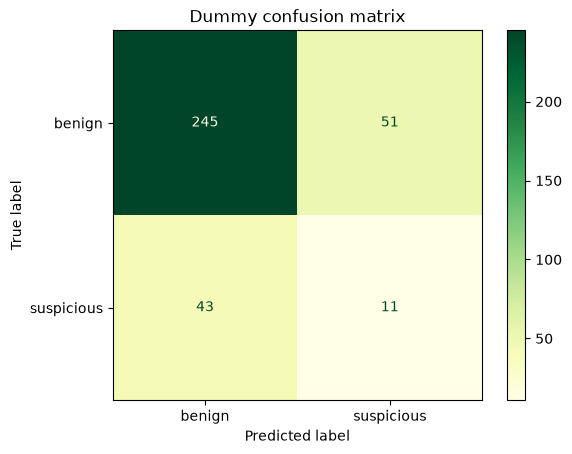

{'accuracy': 0.7314285714285714,
 'balanced_accuracy': 0.5157032032032032,
 'precision': 0.1774193548387097,
 'recall': 0.2037037037037037,
 'f1': 0.1896551724137931,
 'roc_auc': 0.5157032032032033}

In [4]:
dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
evaluate_model("Dummy", dummy, show_details=True)

## 4. Fit one controlled decision tree

| Parameter | Teaching interpretation |
|---|---|
| `criterion` | Split score, commonly `gini` or `entropy` |
| `splitter` | Best available split or a randomized candidate |
| `max_depth` | Maximum rule-chain length |
| `min_samples_split` | Minimum rows required to split a node |
| `min_samples_leaf` | Minimum support retained in every leaf |
| `max_features` | Feature candidates considered per split |
| `class_weight` | Relative error cost by class |
| `ccp_alpha` | Cost-complexity pruning strength |
| `random_state` | Reproducible randomized behavior |

Decision tree
              precision    recall  f1-score   support

      benign       0.96      0.66      0.78       296
  suspicious       0.32      0.85      0.46        54

    accuracy                           0.69       350
   macro avg       0.64      0.76      0.62       350
weighted avg       0.86      0.69      0.73       350



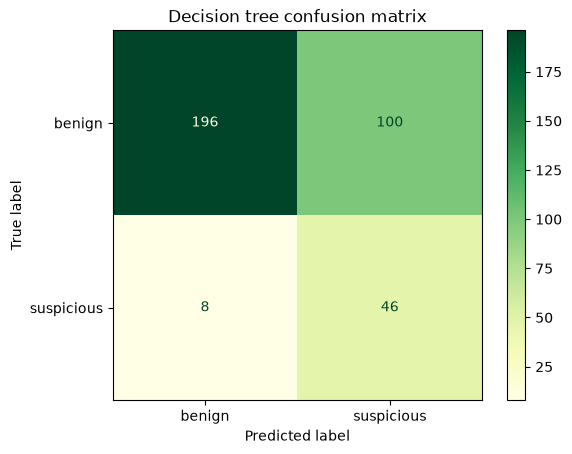

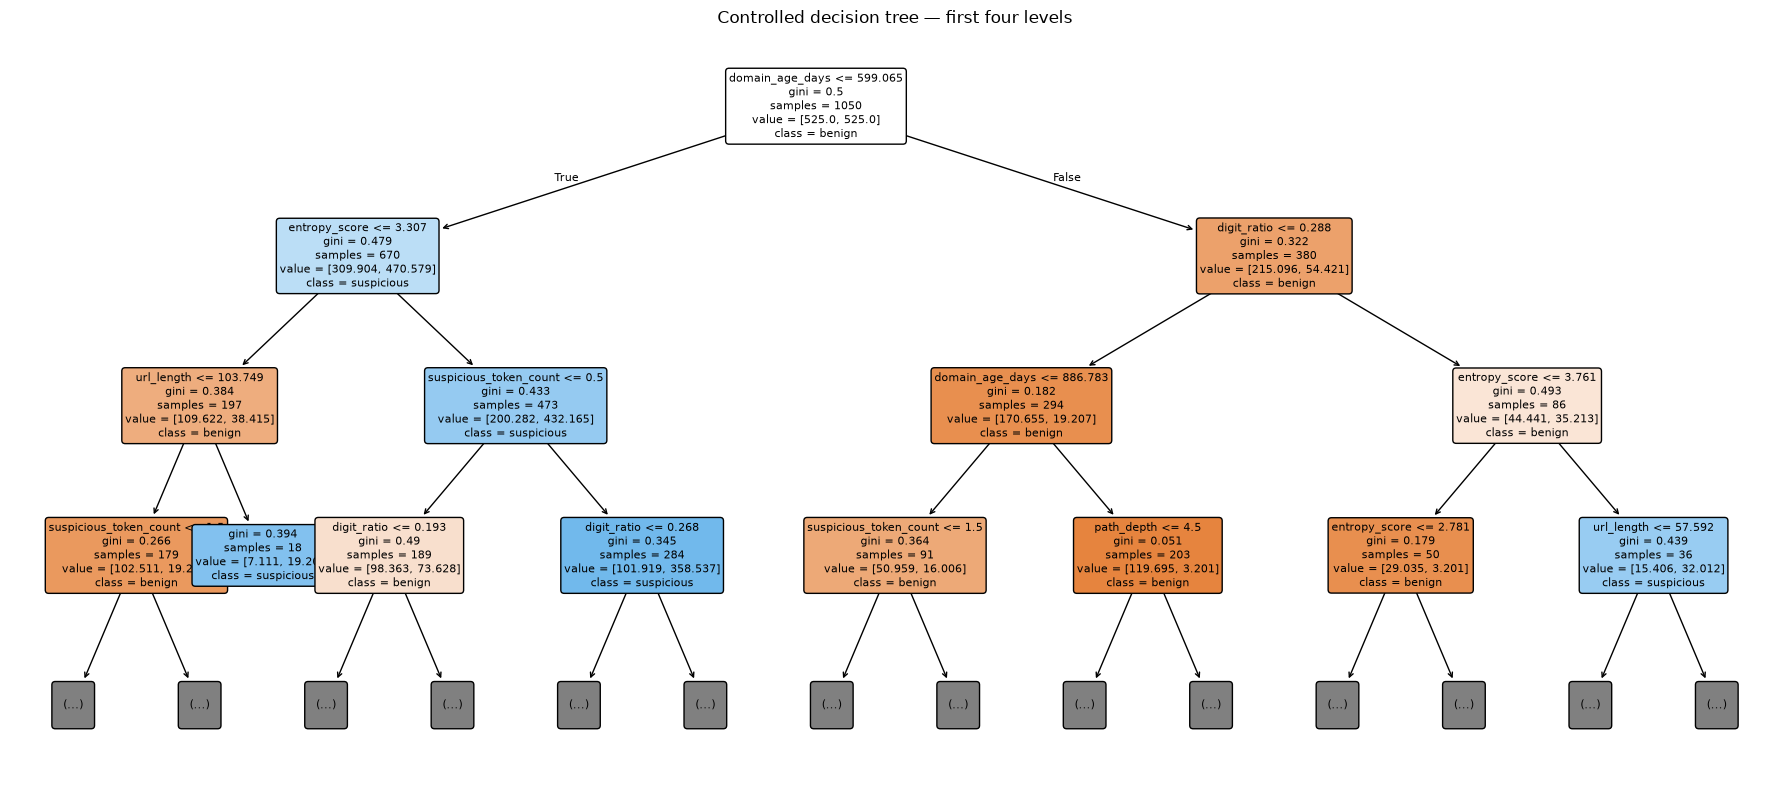

In [5]:
tree = DecisionTreeClassifier(
    criterion="gini",
    splitter="best",
    max_depth=4,
    min_samples_split=24,
    min_samples_leaf=12,
    max_features=None,
    class_weight="balanced",
    ccp_alpha=0.001,
    random_state=RANDOM_STATE,
)
tree.fit(X_train, y_train)
evaluate_model("Decision tree", tree, show_details=True)

plt.figure(figsize=(18, 8))
plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["benign", "suspicious"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8,
)
plt.title("Controlled decision tree — first four levels")
plt.tight_layout()
plt.show()

## 5. Compare tree depth and overfitting

Increasing depth usually improves training fit first. A widening train–test gap marks variance growth. The held-out partition remains untouched by fitting, but a production workflow would select depth with cross-validation on the training partition and reserve a final test set.

  max_depth  train_balanced_accuracy  test_balanced_accuracy
0         1                    0.653                   0.626
1         2                    0.721                   0.675
2         3                    0.775                   0.748
3         4                    0.815                   0.775
4         6                    0.896                   0.828
5         8                    0.934                   0.808
6        12                    0.976                   0.767
7      None                    0.981                   0.753


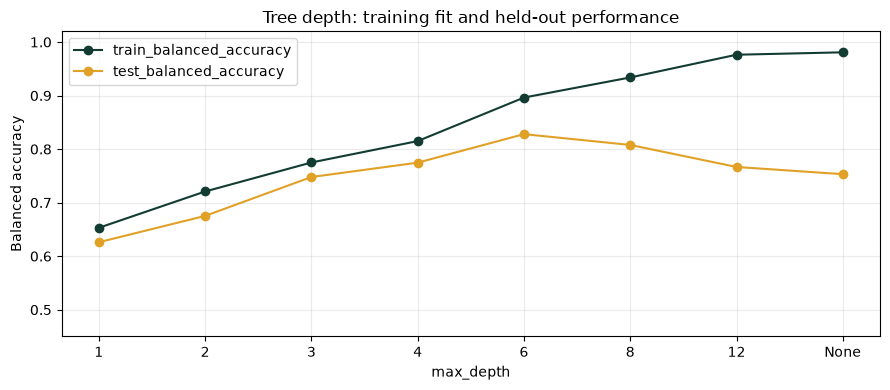

In [6]:
depth_rows = []
for depth in [1, 2, 3, 4, 6, 8, 12, None]:
    candidate = DecisionTreeClassifier(
        max_depth=depth,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ).fit(X_train, y_train)
    depth_rows.append({
        "max_depth": "None" if depth is None else str(depth),
        "train_balanced_accuracy": balanced_accuracy_score(y_train, candidate.predict(X_train)),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, candidate.predict(X_test)),
    })

depth_results = pd.DataFrame(depth_rows)
print(depth_results.round(3))
ax = depth_results.set_index("max_depth").plot(
    marker="o", figsize=(9, 4), color=["#123c32", "#e0a126"]
)
ax.set_ylim(0.45, 1.02)
ax.set_ylabel("Balanced accuracy")
ax.set_title("Tree depth: training fit and held-out performance")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 6. Bagging and random forests

`BaggingClassifier` varies rows through bootstrap sampling and can also vary features. Its main controls are `estimator`, `n_estimators`, `max_samples`, `max_features`, `bootstrap`, `oob_score`, `n_jobs`, and `random_state`.

`RandomForestClassifier` adds split-level feature randomness. Its important controls are `n_estimators`, `criterion`, `max_depth`, `min_samples_leaf`, `max_features`, `class_weight`, `bootstrap`, `oob_score`, `n_jobs`, and `random_state`.

Bagging OOB score: 0.853
Random forest
              precision    recall  f1-score   support

      benign       0.94      0.95      0.95       296
  suspicious       0.72      0.67      0.69        54

    accuracy                           0.91       350
   macro avg       0.83      0.81      0.82       350
weighted avg       0.91      0.91      0.91       350



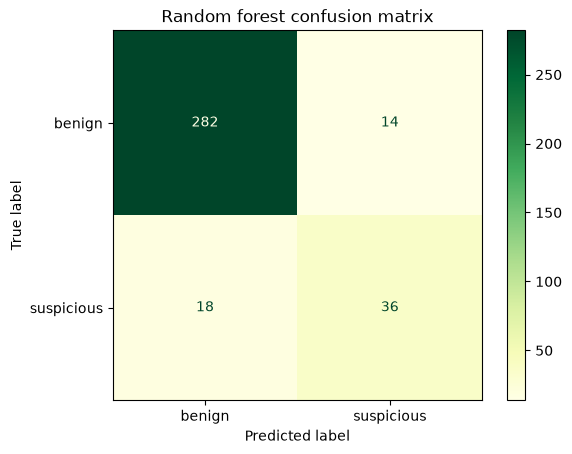

Random forest OOB score: 0.879


In [7]:
base_tree = DecisionTreeClassifier(
    max_depth=5, min_samples_leaf=8, class_weight="balanced", random_state=RANDOM_STATE
)
bagging = BaggingClassifier(
    estimator=base_tree,
    n_estimators=120,
    max_samples=0.8,
    max_features=0.9,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)
evaluate_model("Bagging", bagging)
print("Bagging OOB score:", round(bagging.oob_score_, 3))

forest = RandomForestClassifier(
    n_estimators=250,
    criterion="gini",
    max_depth=8,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced_subsample",
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)
evaluate_model("Random forest", forest, show_details=True)
print("Random forest OOB score:", round(forest.oob_score_, 3))

## 7. Held-out permutation importance

Permutation importance measures the performance loss after one test feature is shuffled. It is model- and dataset-specific evidence, not proof of causality. Correlated features can divide or mask importance.

                  feature  mean_importance  std_importance
1             digit_ratio           0.1326          0.0237
0              url_length           0.1186          0.0204
3  suspicious_token_count           0.1101          0.0133
4         domain_age_days           0.0784          0.0278
2           entropy_score           0.0592          0.0285
5      message_link_count           0.0131          0.0166
6              path_depth           0.0075          0.0132


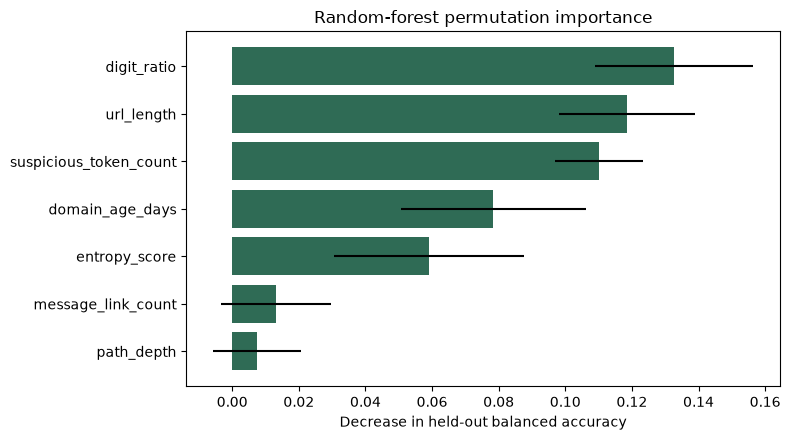

In [8]:
perm = permutation_importance(
    forest,
    X_test,
    y_test,
    scoring="balanced_accuracy",
    n_repeats=12,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
importance = pd.DataFrame({
    "feature": X.columns,
    "mean_importance": perm.importances_mean,
    "std_importance": perm.importances_std,
}).sort_values("mean_importance", ascending=False)
print(importance.round(4))

plot_data = importance.sort_values("mean_importance")
plt.figure(figsize=(8, 4.5))
plt.barh(
    plot_data["feature"],
    plot_data["mean_importance"],
    xerr=plot_data["std_importance"],
    color="#2f6b55",
)
plt.xlabel("Decrease in held-out balanced accuracy")
plt.title("Random-forest permutation importance")
plt.tight_layout()
plt.show()

## 8. Sequential boosting

AdaBoost reweights observations so later shallow learners emphasize current errors. `estimator`, `n_estimators`, `learning_rate`, and `random_state` are the stable controls used here. The code adds `algorithm='SAMME'` only when the installed scikit-learn signature exposes that parameter.

Histogram gradient boosting adds learners to reduce a differentiable loss. Important controls include `learning_rate`, `max_iter`, `max_leaf_nodes`, `max_depth`, `min_samples_leaf`, `l2_regularization`, `early_stopping`, `validation_fraction`, and `random_state`.

Hist gradient boosting
              precision    recall  f1-score   support

      benign       0.91      0.96      0.93       296
  suspicious       0.69      0.46      0.56        54

    accuracy                           0.89       350
   macro avg       0.80      0.71      0.74       350
weighted avg       0.87      0.89      0.88       350



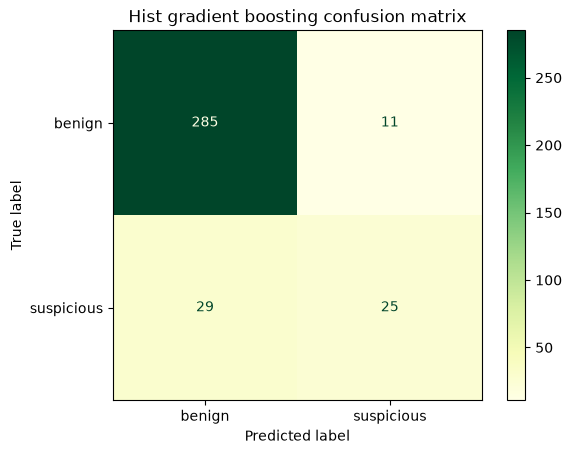

{'accuracy': 0.8857142857142857,
 'balanced_accuracy': 0.7129004004004004,
 'precision': 0.6944444444444444,
 'recall': 0.46296296296296297,
 'f1': 0.5555555555555556,
 'roc_auc': 0.9323073073073074}

In [9]:
ada_kwargs = {
    "estimator": DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    "n_estimators": 120,
    "learning_rate": 0.55,
    "random_state": RANDOM_STATE,
}
if "algorithm" in inspect.signature(AdaBoostClassifier).parameters:
    ada_kwargs["algorithm"] = "SAMME"

ada = AdaBoostClassifier(**ada_kwargs).fit(X_train, y_train)
evaluate_model("AdaBoost", ada)

hist_boost = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=180,
    max_leaf_nodes=15,
    max_depth=None,
    min_samples_leaf=20,
    l2_regularization=0.2,
    early_stopping=True,
    validation_fraction=0.15,
    random_state=RANDOM_STATE,
).fit(X_train, y_train)
evaluate_model("Hist gradient boosting", hist_boost, show_details=True)

## 9. Scaled KNN comparison

KNN performs local voting and stores the training set. Scaling belongs inside the pipeline because distance depends on units. `n_neighbors` controls neighborhood size, `weights` controls vote contribution, `metric` and `p` define distance, `algorithm` and `leaf_size` affect search, and `n_jobs` controls parallel neighbor lookup. High dimensionality makes neighborhoods sparse, prediction cost grows with stored data, and imbalance can dominate unweighted votes. Approximate neighbor search can trade exactness for latency at larger scale.

Scaled KNN
              precision    recall  f1-score   support

      benign       0.89      0.97      0.93       296
  suspicious       0.68      0.31      0.43        54

    accuracy                           0.87       350
   macro avg       0.78      0.64      0.68       350
weighted avg       0.85      0.87      0.85       350



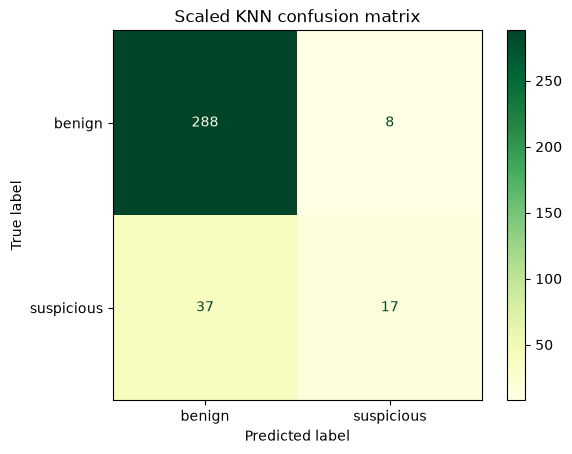

                        accuracy  balanced_accuracy  precision  recall     f1  roc_auc
Bagging                    0.877              0.829      0.577   0.759  0.656    0.925
Random forest              0.909              0.810      0.720   0.667  0.692    0.938
Decision tree              0.691              0.757      0.315   0.852  0.460    0.793
AdaBoost                   0.900              0.736      0.771   0.500  0.607    0.933
Hist gradient boosting     0.886              0.713      0.694   0.463  0.556    0.932
Scaled KNN                 0.871              0.644      0.680   0.315  0.430    0.930
Dummy                      0.731              0.516      0.177   0.204  0.190    0.516


In [11]:
knn = Pipeline([
    ("scale", StandardScaler()),
    ("model", KNeighborsClassifier(
        n_neighbors=15,
        weights="distance",
        metric="minkowski",
        p=2,
        algorithm="auto",
        leaf_size=30,
        n_jobs=-1,
    )),
]).fit(X_train, y_train)
evaluate_model("Scaled KNN", knn, show_details=True)

comparison = pd.DataFrame(results).T.sort_values("balanced_accuracy", ascending=False)
print(comparison.round(3).to_string())

## 10. Multinomial Naive Bayes for synthetic messages

`CountVectorizer` tokenizes text and produces sparse nonnegative token counts. `TfidfVectorizer` downweights terms common across many documents. `MultinomialNB` estimates class-conditional token evidence under a simplifying conditional-independence assumption. Chi-square tests can screen token–label association, but association does not establish semantic meaning or causality.

The main Naive Bayes controls are `alpha` for smoothing, `force_alpha` for preserving the requested smoothing value, `fit_prior` for learning class prevalence, and `class_prior` for an explicit prior.

              precision    recall  f1-score   support

      benign       0.50      0.75      0.60         4
  suspicious       0.50      0.25      0.33         4

    accuracy                           0.50         8
   macro avg       0.50      0.50      0.47         8
weighted avg       0.50      0.50      0.47         8



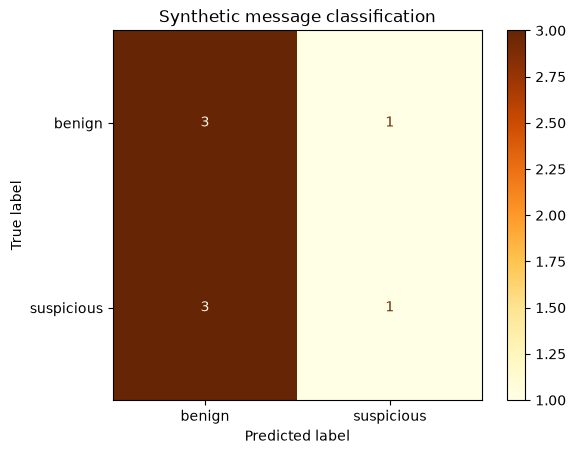

Alternative vectorizer for normalized term weighting
TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)


In [12]:
benign_messages = [
    "team meeting moved to conference room tomorrow",
    "monthly report attached for internal review",
    "security training reminder from learning portal",
    "project notes updated in the shared workspace",
    "lunch order closes at noon today",
    "build completed and test summary is available",
    "calendar invitation for architecture review",
    "benefits enrollment guide posted on intranet",
    "service maintenance window begins Saturday",
    "your requested document is ready in the archive",
    "engineering newsletter for this month",
    "expense report approved by finance team",
]
suspicious_messages = [
    "urgent account verify link expires today",
    "password reset required open secure link now",
    "invoice overdue enable macros to view payment",
    "unusual login confirm credentials immediately",
    "gift reward claim using the attached form",
    "mailbox quota exceeded sign in to restore access",
    "wire transfer request keep this confidential",
    "delivery failed download the tracking document",
    "security alert validate account through this link",
    "payroll update enter banking details today",
    "shared file requires password confirmation",
    "final notice open attachment to avoid suspension",
]
messages = benign_messages + suspicious_messages
message_labels = np.array([0] * len(benign_messages) + [1] * len(suspicious_messages))
msg_train, msg_test, msg_y_train, msg_y_test = train_test_split(
    messages,
    message_labels,
    test_size=0.33,
    stratify=message_labels,
    random_state=RANDOM_STATE,
)

text_model = Pipeline([
    ("vectorizer", CountVectorizer(ngram_range=(1, 2), min_df=1, lowercase=True)),
    ("model", MultinomialNB(alpha=1.0, force_alpha=True, fit_prior=True, class_prior=None)),
]).fit(msg_train, msg_y_train)
msg_pred = text_model.predict(msg_test)
print(classification_report(msg_y_test, msg_pred, target_names=["benign", "suspicious"], zero_division=0))
ConfusionMatrixDisplay.from_predictions(
    msg_y_test, msg_pred, display_labels=["benign", "suspicious"], cmap="YlOrBr"
)
plt.title("Synthetic message classification")
plt.show()

print("Alternative vectorizer for normalized term weighting")
print(TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True))

## 11. Inspect estimator parameters

`get_params(deep=True)` exposes configuration without relying on memory. Pipeline parameters use double-underscore paths such as `model__n_neighbors` and `vectorizer__ngram_range`.

In [13]:
important_parameter_names = {
    "Decision tree": ["criterion", "splitter", "max_depth", "min_samples_split", "min_samples_leaf", "max_features", "class_weight", "ccp_alpha", "random_state"],
    "Bagging": ["estimator", "n_estimators", "max_samples", "max_features", "bootstrap", "oob_score", "n_jobs", "random_state"],
    "Random forest": ["n_estimators", "criterion", "max_depth", "min_samples_leaf", "max_features", "class_weight", "bootstrap", "oob_score", "n_jobs", "random_state"],
    "AdaBoost": ["estimator", "n_estimators", "learning_rate", "algorithm", "random_state"],
    "Hist gradient boosting": ["learning_rate", "max_iter", "max_leaf_nodes", "max_depth", "min_samples_leaf", "l2_regularization", "early_stopping", "validation_fraction", "random_state"],
    "KNN pipeline": ["model__n_neighbors", "model__weights", "model__metric", "model__p", "model__algorithm", "model__leaf_size", "model__n_jobs"],
    "Text pipeline": ["vectorizer__ngram_range", "vectorizer__min_df", "model__alpha", "model__force_alpha", "model__fit_prior", "model__class_prior"],
}
models = {
    "Decision tree": tree,
    "Bagging": bagging,
    "Random forest": forest,
    "AdaBoost": ada,
    "Hist gradient boosting": hist_boost,
    "KNN pipeline": knn,
    "Text pipeline": text_model,
}

parameter_rows = []
for model_name, model in models.items():
    params = model.get_params(deep=True)
    for parameter in important_parameter_names[model_name]:
        if parameter in params:
            parameter_rows.append({
                "model": model_name,
                "parameter": parameter,
                "value": repr(params[parameter]),
            })
parameter_table = pd.DataFrame(parameter_rows)
parameter_table

,model,parameter,value
0,Decision tree,criterion,'gini'
1,Decision tree,splitter,'best'
2,Decision tree,max_depth,4
3,Decision tree,min_samples_split,24
4,Decision tree,min_samples_leaf,12
5,Decision tree,max_features,None
6,Decision tree,class_weight,'balanced'
7,Decision tree,ccp_alpha,0.001
8,Decision tree,random_state,207
9,Bagging,estimator,DecisionTreeClassifier(class_weight='balanced'...


## 12. Optional guided modifications

Apply these changes one at a time and rerun the affected cell plus the metrics table.

1. Increase tree pruning by setting `ccp_alpha` to `0.005`, then compare leaf count and minority recall.
2. Replace balanced tree weights with `None`, then inspect changes in the confusion matrix.
3. Increase the forest from 250 to 500 trees, then compare runtime, OOB score, and held-out metrics.
4. Reduce the boosting learning rate and increase iteration count to preserve total learning capacity.
5. Compare KNN neighborhoods of 5, 15, and 35 with uniform and distance-weighted voting.
6. Replace `CountVectorizer` with `TfidfVectorizer`, then compare unigrams with `(1, 2)` n-grams.
7. Preserve the same split and random state so each comparison isolates the declared change.

## 13. Implementation summary

- Evaluation starts with a leakage-conscious split, a baseline, confusion matrices, class-specific metrics, and ROC AUC.
- One tree offers an inspectable rule path; depth, leaf support, class weighting, and pruning control overfit.
- Bagging averages independently resampled trees to reduce variance; random forests add feature randomness and OOB diagnostics.
- Boosting builds shallow learners sequentially to correct remaining loss.
- KNN needs train-only scaling and careful neighborhood, distance, imbalance, dimensionality, and latency choices.
- Count or TF-IDF features pair naturally with Multinomial Naive Bayes for a compact text baseline.
- Synthetic teaching performance does not establish production readiness, causal indicators, or safe operational thresholds.